In [1]:
import GPUtil

# GPU 상태 정보 출력
gpus = GPUtil.getGPUs()
for gpu in gpus:
    print(f"GPU ID: {gpu.id}")
    print(f"사용 중 메모리: {gpu.memoryUsed} MB")
    print(f"전체 메모리: {gpu.memoryTotal} MB")
    print(f"사용률: {gpu.memoryUtil * 100:.2f}%")

GPU ID: 0
사용 중 메모리: 2.0 MB
전체 메모리: 16376.0 MB
사용률: 0.01%


In [2]:
import os

# 클래스별 폴더 및 이미지 파일 확인
data_dir = "/workspace/dataset/crop/train"
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):  # 클래스 폴더 확인
        print(f"Class: {class_name}")
        images = os.listdir(class_path)
        print(f"  Number of images: {len(images)}")
    else:
        print(f"{class_path} is not a directory!")


Class: anger
  Number of images: 1480
Class: happy
  Number of images: 1465
Class: panic
  Number of images: 1483
Class: sadness
  Number of images: 1463


In [3]:
# 지원되지 않는 확장자 확인
unsupported_extensions = []
for root, dirs, files in os.walk(data_dir):
    for file in files:
        if not file.lower().endswith(('jpg', 'jpeg', 'png')):
            unsupported_extensions.append(file)
print("Unsupported files:", unsupported_extensions)


Unsupported files: []


In [4]:
from datasets import load_dataset

# 각각의 데이터 경로에서 데이터셋 로드
dataset = load_dataset("imagefolder", data_dir="/workspace/dataset/crop")


# 데이터셋 확인
print(dataset)


/root/miniconda3/envs/kms/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5891
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 1166
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1170
    })
})


In [5]:
for example in dataset['train']:
    image = example['image']
    print(image.size)  # (width, height, channels) 출력
    break

image = dataset['train'][0]['image']
print(image.mode) 

(992, 1332)
RGB


In [6]:
from transformers import AutoImageProcessor
import torchvision.transforms as transforms
from datasets import concatenate_datasets

# 이미지 프로세서 (전처리기) 불러오기
processor = AutoImageProcessor.from_pretrained("facebook/deit-base-patch16-224", size={"height": 224, "width": 224})

# 데이터 증강 파이프라인 정의
augmentations = transforms.Compose([
    transforms.RandomHorizontalFlip(),    # 랜덤 좌우 반전
    transforms.ColorJitter(               # 색상 변화
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1
    ),
])

# 전처리 함수 정의 (증강 적용)
def preprocess_images(examples):
    images = examples['image']
    augmented_images = []

    for img in images:
        if img.mode != 'RGB':
            img = img.convert('RGB') 
        if img.size != (224, 224):  # 크기가 다른 경우만 조정
            img = img.resize((224, 224))

        # 데이터 증강 적용
        img = augmentations(img)
        augmented_images.append(img)

    # processor로 전처리 (증강 후, PIL 이미지 대신 텐서 사용 가능)
    inputs = processor(images=augmented_images, return_tensors="pt")
    inputs['label'] = examples['label']  # 라벨 추가
    return inputs

# 전처리 함수 정의 (증강 없이)
def preprocess_images_without_augmentation(examples):
    images = examples['image']
    processed_images = []

    for img in images:
        if img.mode != 'RGB':
            img = img.convert('RGB')
        if img.size != (224, 224):  # 크기가 다른 경우만 조정
            img = img.resize((224, 224))
            
        processed_images.append(img)

    inputs = processor(images=processed_images, return_tensors="pt")
    inputs['label'] = examples['label']
    return inputs

# 데이터셋에 전처리 적용
# dataset = dataset.map(preprocess_images_without_augmentation, batched=True)  # 원본 데이터셋

train_dataset_original = dataset['train'].map(preprocess_images_without_augmentation, batched=True) # 원본 데이터셋에 대한 전처리 (증강 없음)
train_dataset_augmented = dataset['train'].map(preprocess_images, batched=True) # 증강된 데이터셋
train_dataset = concatenate_datasets([train_dataset_original, train_dataset_augmented]) # 원본 데이터셋과 증강된 데이터셋을 결합

# 데이터셋을 셔플하고 나서 train_dataset을 만들기
train_dataset = train_dataset.shuffle()  # 데이터셋을 셔플
val_dataset = dataset['validation'].map(preprocess_images_without_augmentation, batched=True)  # 검증 데이터는 원본 그대로 사용
test_dataset = dataset['test'].map(preprocess_images_without_augmentation, batched=True)  # 테스트 데이터는 원본 그대로 사용


2024-12-24 01:14:11.535269: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1735002851.565197   11203 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1735002851.574656   11203 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [7]:
print(train_dataset.column_names)  # 데이터셋의 필드 확인


['image', 'label', 'pixel_values']


In [8]:
print(processor)


ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [9]:
print(train_dataset.shape)
print(val_dataset.shape)

(11782, 3)
(1166, 3)


In [9]:
train_dataset = train_dataset.shuffle(seed=42)  # 데이터셋을 셔플

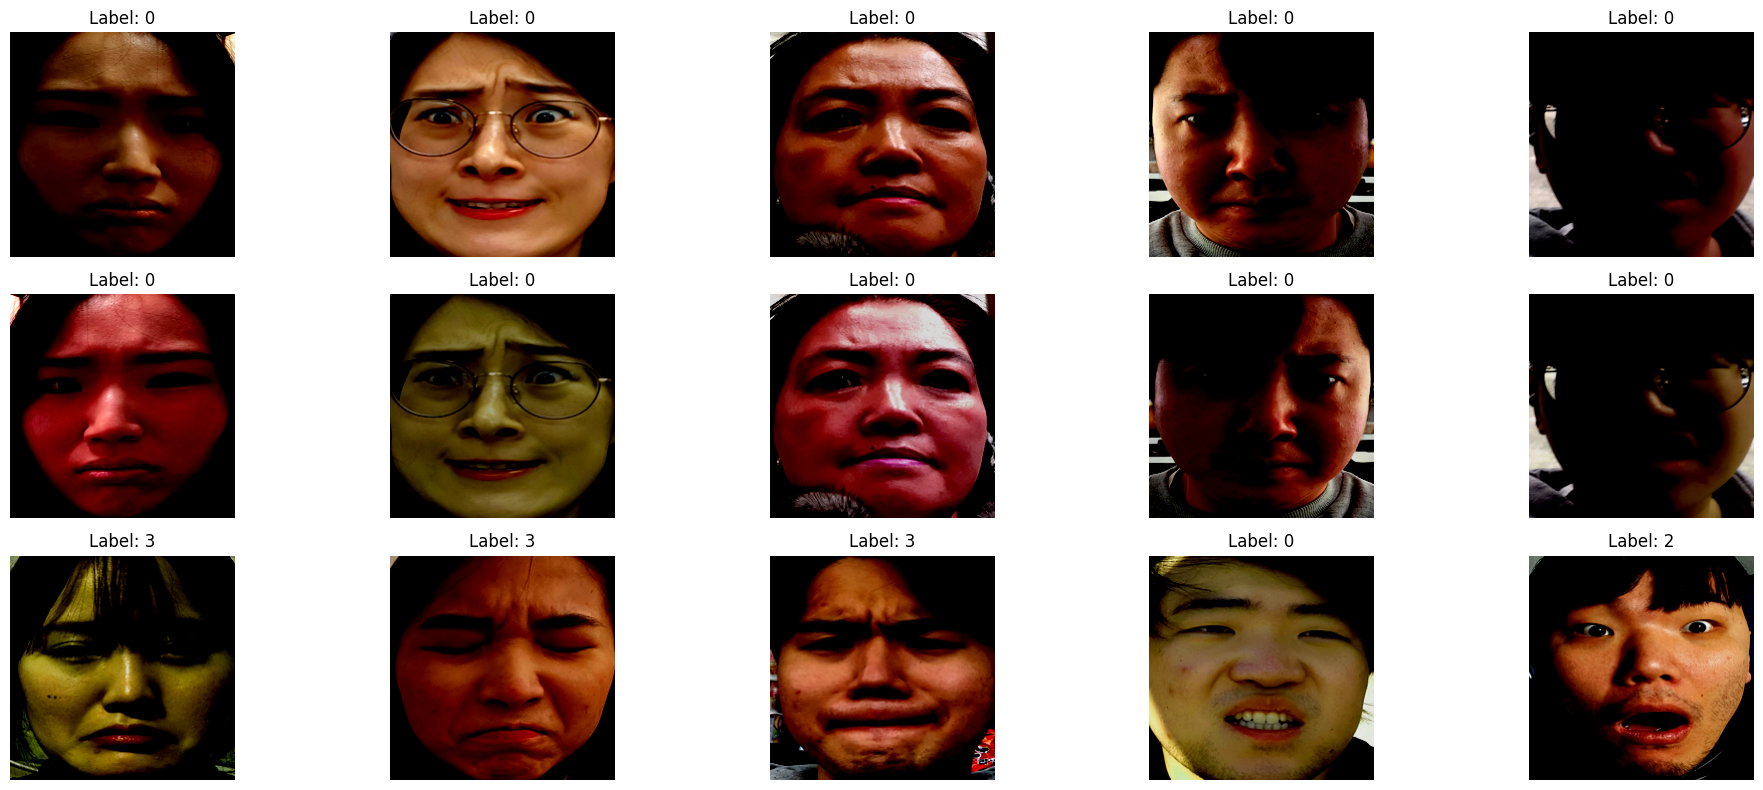

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

# train_original과 train_augment에서 5개 샘플 가져오기
original_samples = train_dataset_original[:5]  # train_original에서 첫 5개 샘플
augment_samples = train_dataset_augmented[:5]    # train_augment에서 첫 5개 샘플
train_shuffled = train_dataset.shuffle()
shuffled_samples = train_shuffled[:5]

# 시각화를 위해 두 줄(2 x 5)로 구성
fig, axes = plt.subplots(3, 5, figsize=(20, 8))  # 2행 5열, 크기 설정

'''
# Helper function: 이미지 변환 및 시각화
def visualize_sample(ax, pixel_values, label):
    # 리스트를 텐서로 변환 (필요 시)
    if isinstance(pixel_values, list):
        pixel_values = torch.tensor(pixel_values)
    
    # 텐서를 numpy 배열로 변환
    img_array = pixel_values.permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
    
    # 정규화된 값을 [0, 255]로 변환
    img_array = (img_array * 255).clip(0, 255).astype(np.uint8)
    
    # numpy 배열을 PIL 이미지로 변환
    img = Image.fromarray(img_array)
    
    # 이미지 표시
    ax.imshow(img)
    ax.set_title(f"Label: {label}")
    ax.axis('off')  # 축 숨기기
'''    
    
def visualize_sample(ax, pixel_values, label):
    # 리스트를 텐서로 변환 (필요 시)
    if isinstance(pixel_values, list):
        pixel_values = torch.tensor(pixel_values)
    
    # 텐서를 numpy 배열로 변환
    img_array = pixel_values.permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
    
    # 정규화된 값을 [0, 255]로 변환, 정규화 범위가 0-1인 경우
    img_array = np.clip(img_array * 255, 0, 255).astype(np.uint8)
    
    # numpy 배열을 PIL 이미지로 변환
    img = Image.fromarray(img_array)
    
    # 이미지 표시
    ax.imshow(img)
    ax.set_title(f"Label: {label}")
    ax.axis('off')  # 축 숨기기


# 첫 줄: train_original
for i, ax in enumerate(axes[0]):
    visualize_sample(ax, original_samples['pixel_values'][i], original_samples['label'][i])

# 두 번째 줄: train_augment
for i, ax in enumerate(axes[1]):
    visualize_sample(ax, augment_samples['pixel_values'][i], augment_samples['label'][i])

# 세 번째 줄: train_con_shuffled
for i, ax in enumerate(axes[2]):
    visualize_sample(ax, shuffled_samples['pixel_values'][i], shuffled_samples['label'][i])

# 시각화
plt.tight_layout()
plt.show()




In [13]:
from transformers import DeiTForImageClassification, TrainingArguments, Trainer, EarlyStoppingCallback

# vit = google/vit-base-patch16-224-in21k / ViTForImageClassification
# 모델 불러오기
model = DeiTForImageClassification.from_pretrained(
    'facebook/deit-base-distilled-patch16-224',
    num_labels=4  # 클래스 수
)

'''
# 분류 레이어만 학습 가능하도록 설정
for name, param in model.named_parameters():
    if 'classifier' in name:  # 'classifier'가 이름에 포함된 파라미터
        param.requires_grad = True
    else:
        param.requires_grad = False
'''


training_args = TrainingArguments(
    output_dir="./vit_output",  # 학습 결과를 저장할 디렉터리
    evaluation_strategy="epoch",  # 매 에폭마다 검증 진행
    save_strategy="epoch",  # 매 에폭마다 모델 저장
    learning_rate=1e-4,  # 학습률 설정 (값을 낮춰 안정적으로 학습)
    per_device_train_batch_size=64,  # 학습 시 장치별 배치 크기 (값을 줄여 메모리 사용량 감소)
    per_device_eval_batch_size=64,  # 평가 시 장치별 배치 크기
    num_train_epochs=15,  # 전체 학습 에폭 수
    weight_decay=0.1,  # 가중치 감쇠율 (값을 증가시켜 과적합 방지)
    logging_dir="./logs",  # 로그 데이터를 저장할 디렉터리
    logging_steps=50,  # 로그 출력 빈도 (50 스텝마다 기록)
    load_best_model_at_end=True,  # 학습 종료 시 가장 좋은 모델 로드
    lr_scheduler_type="cosine",  # 학습률 감소 스케줄러로 코사인 스케줄 사용
    warmup_steps=500,  # 학습률 워밍업 단계 (500 스텝 동안 서서히 증가)
    fp16=True,  # 혼합 정밀도 학습 사용 (메모리 효율 및 속도 향상)
    max_grad_norm=1.0,  # 그래디언트 클리핑 값 설정 (값을 제한하여 안정성 향상)
    dataloader_num_workers=2,  # 데이터 로더의 워커 프로세스 수 (병렬 처리로 속도 향상)
    gradient_accumulation_steps=4,  # 그래디언트 누적 스텝 (메모리 효율 개선)
    metric_for_best_model="eval_loss"  # 가장 좋은 모델 판단 기준 (검증 손실)
)



# Trainer 정의
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,  # 학습 데이터셋
    eval_dataset=val_dataset,     # 검증 데이터셋
    tokenizer=None,          # 이미지 전처리기 전달 (이미지 처리용)
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]  # 조기 종료 설정
)

# 모델 학습
trainer.train()


Some weights of DeiTForImageClassification were not initialized from the model checkpoint at facebook/deit-base-distilled-patch16-224 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/root/miniconda3/envs/kms/lib/python3.10/site-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_11203/3698704310.py:44: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,No log,1.206067
2,1.328000,0.731214
3,0.678900,0.623704
4,0.348900,0.824238
5,0.178000,0.806805
6,0.059800,0.996925


TrainOutput(global_step=282, training_loss=0.46386740309126834, metrics={'train_runtime': 5518.0692, 'train_samples_per_second': 32.028, 'train_steps_per_second': 0.125, 'total_flos': 5.478259994751173e+18, 'train_loss': 0.46386740309126834, 'epoch': 6.0})

In [9]:
# 평가
results = trainer.evaluate()
print("Evaluation Results:", results)


Evaluation Results: {'eval_loss': 1.3956459760665894, 'eval_runtime': 44.1413, 'eval_samples_per_second': 26.415, 'eval_steps_per_second': 1.654, 'epoch': 9.948509485094851}


In [14]:
import torch
from sklearn.metrics import accuracy_score

# 모델 예측
predictions = trainer.predict(test_dataset)

# 예측 라벨 계산 (logits에서 가장 큰 값의 인덱스를 선택)
predicted_labels = torch.argmax(torch.tensor(predictions.predictions), dim=-1)

# 실제 라벨
true_labels = torch.tensor(predictions.label_ids)

# 정확도 계산
accuracy = accuracy_score(true_labels.numpy(), predicted_labels.numpy())
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.8034


In [ ]:
from transformers import ViTForImageClassification

# 저장된 모델 불러오기
best_model = ViTForImageClassification.from_pretrained("./vit_output/checkpoint-738")


In [21]:
best_model = trainer.model

In [24]:
output_model_dir = "/workspace/kms/models/vit-8444"
trainer.save_model(output_model_dir)